# TD(0) and n-Step TD Algorithms

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand Temporal Difference (TD) learning
- Implement TD(0) algorithm
- Implement n-step TD algorithms
- Compare TD with Monte Carlo methods
- Apply TD algorithms to RL environments

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 2, lesson 03 "Gradient Descent Implementation" — the TD update V(s) ← V(s) + α·(target − V(s)) is the same step-toward-a-target move, with the same learning-rate trade-off; what is new is that the target is itself an estimate that is still changing.

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 2**:
- Running TD(0) and n-step TD algorithms in simple RL environments

---

## Introduction

**Temporal Difference (TD) learning** combines ideas from Monte Carlo (learning from experience) and Dynamic Programming (bootstrapping). TD methods update estimates based on other estimates, making them more sample-efficient than Monte Carlo.
> **🔤 Notation warning — same quantity, two letters across the diploma.** In this course the
> learning rate (step size) is written **α**, following Sutton & Barto, *Reinforcement Learning: An
> Introduction* (2e) — the standard text for the field. Course 08 (AIAT 122), Unit 1, lessons 05–06
> wrote the *same* quantity as **η** in \(w_{t+1} = w_t - \eta\,g_t\), following the deep-learning
> convention, and Course 03 (AIAT 113) spelled it out as `learning_rate`. One idea, three notations,
> because three literatures settled on different letters — there is no disagreement about the
> mathematics. Note also that this α is **not** the α of Course 03 Unit 5 (significance level) or of
> Course 03/Course 04 Ridge and Lasso (regularization strength). See `docs/GLOSSARY.md`.

## Lesson Brief

This lesson introduces **temporal-difference learning**, especially TD(0) and n-step ideas.

Students will see how an agent can learn before an episode finishes by bootstrapping from current estimates.

Why this matters: TD methods are central to modern RL because they mix observed rewards with learned predictions.

This lesson connects Monte Carlo intuition to scalable online learning.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: a backgammon program in 1992, and a monkey's brain in 1997

**The program.** Gerald Tesauro's **TD-Gammon** (IBM; "Temporal difference learning and TD-Gammon",
*Communications of the ACM* **38**(3), 1995) was a neural network trained by TD(λ) on games it played
against itself — about **1.5 million** of them for version 2.1. No opening book, no human games, no
hand-written evaluation. It reached a level just below the world's best human players. More
striking: it played opening moves that human masters had considered inferior, those moves were
re-examined, and backgammon opening theory changed. A learning rule that updates on *the difference
between two consecutive estimates* rewrote the received wisdom of a game people had played for 5,000
years.

**The brain.** Five years later, Schultz, Dayan and Montague published "A Neural Substrate of
Prediction and Reward" (*Science* **275**, 1593–1599, 1997). Recording single dopamine neurons in the
primate midbrain, they found the firing pattern did not track reward. It tracked the *error* between
predicted and received reward: a burst for an unexpected reward, almost nothing for a fully predicted
one, and a dip below baseline at the exact moment an expected reward failed to arrive. That is the TD
error, `r + γV(s') − V(s)`, the quantity the very first code cell below computes as **1.70**.

**What goes wrong without this.** Monte Carlo, the previous lesson, cannot update until an episode
ends. TD updates after a single step, using its own current estimate of what comes next. That one
change is what makes learning possible in problems that never end and in systems that must improve
while they run — and it is why the same rule turned up independently in a machine and in a brain.


## Recommended YouTube Video

To reinforce this lesson, watch **RTG Computational Cognition - "Reinforcement Learning Crash Course - n-step TD Learning"**:
[Watch on YouTube](https://www.youtube.com/watch?v=FQlnE44Lha0)

Why this pick:
- Clear English lecture style and focused explanation.
- Shows how n-step TD bridges one-step TD and Monte Carlo ideas.
- Useful when students need intuition for why bootstrapping depth matters.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Bootstrapping: learning from an estimate of future value instead of waiting for the full return.
- TD error: target minus current estimate.
- TD(0): one-step update using immediate reward plus one estimated future value.
- n-step return: several real rewards first, then bootstrap.

### Quick Check
- Why can bootstrapping speed learning?
- How does n-step sit between MC and TD(0)?
- What does a large TD error mean?
- Why is TD often more online than Monte Carlo?

### Common Mistakes
- Thinking bootstrapping is invalid.
- Seeing TD(0) and n-step as unrelated.
- Losing track of where reward stops and estimate begins.
- Forgetting that TD trades some variance reduction for bias and speed.


## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


## TD Learning in Plain Language

Temporal-difference learning keeps the Monte Carlo idea of learning from experience, but it stops waiting for the episode to finish.

### The core idea

Instead of saying:

`I will wait until I know the full return.`

TD says:

`I already know something useful now, so I can update earlier.`

That is where bootstrapping comes from.

### Monte Carlo vs TD

- **Monte Carlo**: wait for the full episode, then use the real return.
- **TD(0)**: use one real reward now, then rely on an estimate for the rest.

So TD is usually faster and more online, but it depends on current estimates that may still be imperfect.

### Where does n-step fit?

n-step TD is the middle ground:

- use several real rewards first
- then bootstrap from an estimate

That is why students should think of n-step as a bridge between Monte Carlo and TD(0), not as a completely separate family.

### Classroom intuition

Bootstrapping is not "guessing randomly."
It is reusing the best estimate the agent currently has so learning can begin earlier.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt
# Load a library so you can use its ready-made functions and types below.
from collections import defaultdict

# Show text or numbers in the cell output area under the code.
print("✅ Libraries imported!")
# Show text or numbers in the cell output area under the code.
print("\nTD(0) and n-Step TD Algorithms")
# Show text or numbers in the cell output area under the code.
print("=" * 60)


✅ Libraries imported!

TD(0) and n-Step TD Algorithms


## Part 1: Understanding TD Learning


### Step Guide

**What this cell does:** Computes **one single TD(0) update by hand** with tiny concrete numbers: the TD target, the TD error, and the corrected value.

**How to read it (weak Python OK):** Five named numbers go in (`v_s`, `reward`, `v_s_next`, `gamma`, `alpha`); three computed numbers come out. Check each printed line with mental arithmetic.

**What to expect in the output:** A short table of the ingredients and the updated value `V(s)`.

**If you feel lost:** Keep only one sentence: the update mixes *one real reward* with *an existing estimate* — that mix is bootstrapping.

In [2]:
# Part 1: Understanding TD Learning — one single TD(0) update computed by hand.
# Seeing the formula once with real numbers makes the training loops below much easier to read.

# Print the section banner so the output matches the notebook headers.
print("=" * 60)
print("Part 1: Understanding TD Learning")
print("=" * 60)

# The agent sits in state s with an existing estimate, then observes ONE step of experience.
v_s = 2.0        # current estimate of V(s) before the update
v_s_next = 3.0   # current estimate of V(s') for the state that followed
reward = 1.0     # the one real reward observed on the transition s -> s'
gamma = 0.9      # discount factor: how much future value still counts
alpha = 0.5      # learning rate: how big a correction step to take

# TD target = one real reward + discounted current estimate of the next state.
td_target = reward + gamma * v_s_next
# TD error = how "surprised" the old estimate was by that target.
td_error = td_target - v_s
# The update moves V(s) a fraction alpha of the way toward the target.
v_s_updated = v_s + alpha * td_error

# Print every ingredient so students can verify the arithmetic by hand.
print(f"\nCurrent estimate V(s)          : {v_s:.2f}")
print(f"Observed reward r              : {reward:.2f}")
print(f"Estimate of next state V(s')   : {v_s_next:.2f}")
print(f"TD target   r + gamma * V(s')  : {td_target:.2f}")
print(f"TD error    target - V(s)      : {td_error:.2f}")
print(f"Updated V(s) after one step    : {v_s_updated:.2f}")

# One-sentence takeaway tying the numbers back to the theory above.
print("\nKey idea: the update used ONE real reward plus an existing estimate --")
print("no waiting for the episode to finish. That is bootstrapping.")


Part 1: Understanding TD Learning

Current estimate V(s)          : 2.00
Observed reward r              : 1.00
Estimate of next state V(s')   : 3.00
TD target   r + gamma * V(s')  : 3.70
TD error    target - V(s)      : 1.70
Updated V(s) after one step    : 2.85

Key idea: the update used ONE real reward plus an existing estimate --
no waiting for the episode to finish. That is bootstrapping.


## Part 2: TD(0) Implementation


### Step Guide

**What this cell does:** Implements **TD(0) prediction** on a classic 5-state random walk whose exact true values are known (1/6 … 5/6), then compares the learned estimates with the truth.

**How to read it (weak Python OK):** `random_walk_episode` rolls one episode; `td0_random_walk` applies the Part 1 update after *every step* of every episode. The final table is the whole point.

**What to expect in the output:** A small state-by-state table of TD(0) estimate vs true value, plus one RMS-error number.

**If you feel lost:** Only compare the two number columns — TD(0) never sees the true values, yet it lands close to them.

In [3]:
# Part 2: TD(0) implementation — estimate state values on a 5-state random walk.
# This tiny chain has KNOWN true values, so we can measure how close TD(0) gets.

# Print the section banner so the output matches the notebook headers.
print("\n" + "=" * 60)
print("Part 2: TD(0) Implementation")
print("=" * 60)

# Fixed seed so the printed numbers are reproducible in class.
rng = np.random.default_rng(42)

# Random-walk chain: states 0..6, terminals at 0 and 6, start in the middle (state 3).
# The only reward is +1 for finishing at the RIGHT terminal (state 6).
N_CHAIN = 7
TRUE_VALUES = np.arange(1, 6) / 6.0   # exact answer for states 1..5: 1/6 .. 5/6


def random_walk_episode(rng):
    """Roll one episode; return the visited states and the single final reward."""
    # Start in the middle of the chain.
    state = 3
    states = [state]
    # Step left or right with equal probability until a terminal is reached.
    while state not in (0, 6):
        state += rng.choice([-1, 1])
        states.append(state)
    # +1 only if the walk ended on the right side.
    reward = 1.0 if state == 6 else 0.0
    return states, reward


def td0_random_walk(episodes=200, alpha=0.1, rng=None):
    """TD(0) prediction with gamma = 1: apply the Part 1 update after every step."""
    # Start every non-terminal at a neutral 0.5; terminals hold value 0.
    values = np.full(N_CHAIN, 0.5)
    values[0] = values[6] = 0.0
    # Learn online: one small update per observed transition.
    for _ in range(episodes):
        states, final_reward = random_walk_episode(rng)
        for t in range(len(states) - 1):
            s, s_next = states[t], states[t + 1]
            # The reward is 0 on every step except entering the right terminal.
            r = final_reward if s_next == 6 else 0.0
            # Same update as Part 1: target = r + V(s'), error, small correction.
            values[s] += alpha * (r + values[s_next] - values[s])
    return values


# Run TD(0) and compare the learned estimates with the exact chain values.
td0_chain_values = td0_random_walk(episodes=200, alpha=0.1, rng=rng)

# Print the comparison table students should study line by line.
print("\nState | TD(0) estimate | true value")
for s in range(1, 6):
    print(f"  {s}   |     {td0_chain_values[s]:.3f}      |   {TRUE_VALUES[s - 1]:.3f}")

# One summary number: root-mean-square error across the five learnable states.
rmse_td0 = np.sqrt(np.mean((td0_chain_values[1:6] - TRUE_VALUES) ** 2))
print(f"\nRMS error after 200 episodes: {rmse_td0:.3f}")
print("TD(0) moved toward the true values without ever being shown them.")



Part 2: TD(0) Implementation

State | TD(0) estimate | true value
  1   |     0.091      |   0.167
  2   |     0.244      |   0.333
  3   |     0.483      |   0.500
  4   |     0.711      |   0.667
  5   |     0.820      |   0.833

RMS error after 200 episodes: 0.057
TD(0) moved toward the true values without ever being shown them.


## Part 3: n-Step TD Implementation


### Step Guide

**What this cell does:** Implements **n-step TD** on the same random walk and compares `n = 1, 3, 5` by their RMS error against the known true values.

**How to read it (weak Python OK):** The only change from Part 2 is the target: sum up to `n` real rewards first, *then* bootstrap from `V`. The small printed table is the result.

**What to expect in the output:** One RMS-error row per `n`, plus a computed line naming which `n` did best *on this run*.

**If you feel lost:** Remember the axis: `n = 1` is TD(0); very large `n` behaves like Monte Carlo. The printed line names the winner for this run only — it is not a law.

In [4]:
# Part 3: n-step TD — same random walk, but each update looks n real steps ahead.
# Comparing n = 1, 3, 5 makes the bridge between TD(0) and Monte Carlo concrete.

# Print the section banner so the output matches the notebook headers.
print("\n" + "=" * 60)
print("Part 3: n-Step TD Implementation")
print("=" * 60)


def n_step_td_random_walk(n, episodes=200, alpha=0.1, seed=7):
    """n-step TD prediction (gamma = 1) on the random-walk chain from Part 2."""
    # Separate generator so every n uses the SAME episode stream (fair comparison).
    rng_local = np.random.default_rng(seed)
    # Neutral start for non-terminals; terminals hold value 0.
    values = np.full(N_CHAIN, 0.5)
    values[0] = values[6] = 0.0
    for _ in range(episodes):
        states, final_reward = random_walk_episode(rng_local)
        T = len(states) - 1   # number of transitions in this episode
        # Reward is 0 everywhere except the step that enters the right terminal.
        rewards = [final_reward if states[t + 1] == 6 else 0.0 for t in range(T)]
        for t in range(T):
            # n-step return: up to n real rewards, then bootstrap from V.
            upper = min(t + n, T)
            # Terminal states keep value 0, so adding values[states[upper]] is always safe.
            g = sum(rewards[t:upper]) + values[states[upper]]
            # Same small-correction update as before, with the longer target.
            values[states[t]] += alpha * (g - values[states[t]])
    return values


# Compare three lookahead depths on identical episode streams.
print("\n  n  | RMS error vs true values (200 episodes, alpha=0.1)")
results_n = {}
for n in (1, 3, 5):
    v = n_step_td_random_walk(n)
    rmse = np.sqrt(np.mean((v[1:6] - TRUE_VALUES) ** 2))
    results_n[n] = rmse
    print(f"  {n}  |  {rmse:.3f}")

# Compute (not assume) which n did best on this particular run.
best_n = min(results_n, key=results_n.get)
print(f"\nOn this run, n={best_n} gave the lowest error.")
print("Larger n uses more real rewards per update (more like Monte Carlo);")
print("smaller n bootstraps sooner (more like TD(0)). Neither extreme always wins.")



Part 3: n-Step TD Implementation

  n  | RMS error vs true values (200 episodes, alpha=0.1)
  1  |  0.038
  3  |  0.073
  5  |  0.092

On this run, n=1 gave the lowest error.
Larger n uses more real rewards per update (more like Monte Carlo);
smaller n bootstraps sooner (more like TD(0)). Neither extreme always wins.


## 🌍 Worked Example — TD Prediction on a Benchmark With a Known Answer

Parts 1-3 used the classic 5-state random walk from Sutton & Barto, where the true values are
`1/6 … 5/6` by hand. Now we do the same job on a **published environment**: Gymnasium's
`FrozenLake-v1` (4x4, slippery).

**Why this environment is worth the switch.** It gives us something a made-up simulator cannot:
a **ground truth we can compute exactly**. Gymnasium publishes the environment's transition
model as `env.unwrapped.P`, so for a fixed policy π we can solve the Bellman equation

  `V = R_π + γ P_π V`

as a linear system and get the exact `V^π`. The TD estimates below are then scored against a
correct answer, not against each other.

**The prediction task:**
- **Policy (fixed, not learned):** always try to move *right*; in the last column, try *down*.
  It is a plausible plan, not an optimal one — prediction asks "how good is *this* policy?",
  not "what is the best policy?".
- **The ice is slippery:** a chosen action succeeds only 1/3 of the time, so the same policy
  produces a different episode every time. That randomness is the environment, and it is
  exactly what TD has to average out.
- **Reward:** `+1` for arriving at the goal, `0` everywhere else — a genuinely sparse signal.

We compare **TD(0)** with **3-step** and **5-step** returns on identical episode streams.

### Step Guide

**What this cell does:** Computes the exact `V^π` for a fixed policy on `FrozenLake-v1` by
solving a linear system from Gymnasium's published model, then learns the same values from
experience with n-step TD for `n = 1, 3, 5` and measures the error against that exact answer.

**How to read it (weak Python OK):** Three blocks — (1) exact answer, (2) the n-step TD learner
(the `n = 1` case *is* TD(0)), (3) the comparison and the error curves.

**What to expect in the output:** the true value of every tile printed as a 4x4 grid, the TD(0)
estimate next to it, a table of final RMS errors per `n`, and a figure showing how the error
falls as episodes accumulate.

**If you feel lost:** compare only the two 4x4 grids. If the learned numbers are close to the
true numbers, TD prediction worked — the rest is how quickly and at what cost.

TD prediction on FrozenLake-v1 (4x4, slippery)
Policy under evaluation (→ = right, ↓ = down):
   →  →  →  ↓
   →  H  →  H
   →  →  →  H
   H  →  →  G

True V^pi (exact, from the published transition model):
[[0.0235 0.0225 0.0486 0.0225]
 [0.0283 0.     0.0824 0.    ]
 [0.0657 0.1793 0.2116 0.    ]
 [0.     0.3546 0.5859 0.    ]]



TD(0) estimate after 3000 episodes (learned from experience only):


[[0.0169 0.0197 0.0397 0.0183]
 [0.0189 0.     0.0685 0.    ]
 [0.0465 0.1457 0.1516 0.    ]
 [0.     0.3393 0.6459 0.    ]]

  n  | RMS error vs the exact V^pi (3000 episodes, alpha=0.05)
  1  |  0.0292   (TD(0))
  3  |  0.0337   (3-step)
  5  |  0.0455   (5-step)

On this run n=1 gave the lowest error.
Reading it honestly: FrozenLake's reward is sparse (+1 only at the goal), so longer
n-step returns carry more of the episode's randomness into each update. Bootstrapping
sooner trades a little bias for a lot less variance here - that is the whole n-step
trade-off, measured rather than asserted.


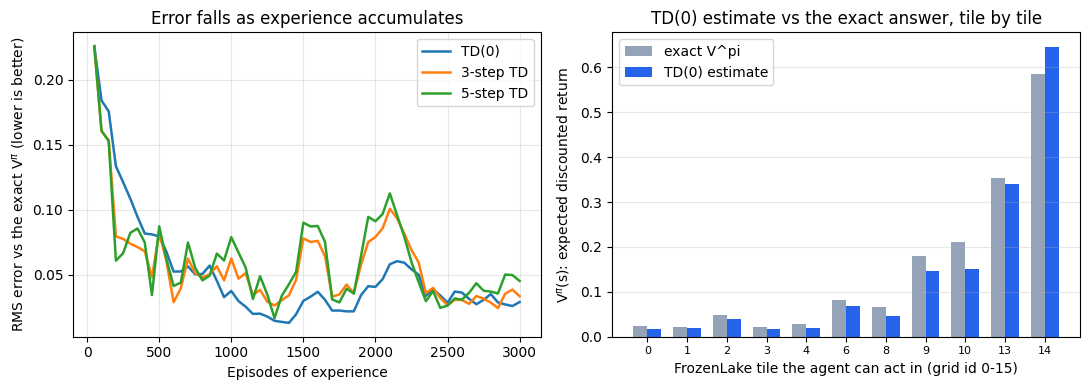

In [5]:
# WHAT: n-step TD prediction on Gymnasium's FrozenLake-v1, scored against the exact V^pi.
# WHY: the value of a benchmark environment here is that its transition model is published, so
#      we can SOLVE for the true values and then show that TD - which never sees that model -
#      recovers them from sampled experience alone.

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
N_STATES, N_ACTIONS = env.observation_space.n, env.action_space.n
GAMMA_FL = 0.95
TILES = env.unwrapped.desc.astype(str).ravel()          # 'S', 'F', 'H', 'G' per state
TERMINAL = {s for s in range(N_STATES) if TILES[s] in ("H", "G")}
NON_TERMINAL = [s for s in range(N_STATES) if s not in TERMINAL]

# The fixed policy we are evaluating: 2 = right, 1 = down (Gymnasium's action ids).
FIXED_POLICY = np.array([2 if (s % 4) < 3 else 1 for s in range(N_STATES)])

print("=" * 64)
print("TD prediction on FrozenLake-v1 (4x4, slippery)")
print("=" * 64)
print("Policy under evaluation (→ = right, ↓ = down):")
for row in range(4):
    print("   " + "  ".join(
        TILES[row * 4 + col] if TILES[row * 4 + col] in ("H", "G")
        else ("→" if FIXED_POLICY[row * 4 + col] == 2 else "↓")
        for col in range(4)))

# ── Block 1: the exact answer, solved from Gymnasium's published model ──────────
# V = R_pi + gamma * P_pi V  rearranges to  (I - gamma P_pi) V = R_pi, a linear solve.
model = env.unwrapped.P
A = np.eye(N_STATES)
b = np.zeros(N_STATES)
for s in range(N_STATES):
    if s in TERMINAL:
        continue                                    # terminal tiles keep value 0
    for probability, next_state, reward, _terminated in model[s][int(FIXED_POLICY[s])]:
        b[s] += probability * reward
        A[s, next_state] -= GAMMA_FL * probability
V_true = np.linalg.solve(A, b)

print("\nTrue V^pi (exact, from the published transition model):")
print(np.round(V_true.reshape(4, 4), 4))


# ── Block 2: learn the same values from sampled experience ─────────────────────
def run_episode(seed=None):
    """Follow the fixed policy for one episode; return the visited states and rewards."""
    state, _ = env.reset(seed=seed) if seed is not None else env.reset()
    states, rewards = [state], []
    for _ in range(200):
        state, reward, terminated, truncated, _ = env.step(int(FIXED_POLICY[state]))
        states.append(state)
        rewards.append(reward)
        if terminated or truncated:
            break
    return states, rewards


def rms_error(V):
    """Root-mean-square gap to the exact answer, over the tiles the agent can act in."""
    return float(np.sqrt(np.mean((V[NON_TERMINAL] - V_true[NON_TERMINAL]) ** 2)))


def n_step_td(n, episodes=3000, alpha=0.05, seed=0):
    """n-step TD prediction. n = 1 IS TD(0): the update from Part 1, applied every step."""
    V = np.zeros(N_STATES)
    error_curve = []
    for episode_index in range(episodes):
        # Seed only the first reset: the environment RNG then rolls on reproducibly.
        states, rewards = run_episode(seed if episode_index == 0 else None)
        T = len(rewards)
        for t in range(T):
            upper = min(t + n, T)
            # Sum the n real rewards we actually collected ...
            G = sum(GAMMA_FL ** (i - t) * rewards[i] for i in range(t, upper))
            # ... then bootstrap with the current estimate, unless the episode already ended.
            if upper < T:
                G += GAMMA_FL ** (upper - t) * V[states[upper]]
            V[states[t]] += alpha * (G - V[states[t]])
        if (episode_index + 1) % 50 == 0:
            error_curve.append(rms_error(V))
    return V, error_curve


# ── Block 3: compare TD(0) with longer n-step returns ──────────────────────────
results, curves = {}, {}
for n in (1, 3, 5):
    V_n, curve = n_step_td(n)
    results[n] = (V_n, rms_error(V_n))
    curves[n] = curve

V_td0 = results[1][0]
print("\nTD(0) estimate after 3000 episodes (learned from experience only):")
print(np.round(V_td0.reshape(4, 4), 4))

print("\n  n  | RMS error vs the exact V^pi (3000 episodes, alpha=0.05)")
for n, (_, err) in results.items():
    label = "TD(0)" if n == 1 else f"{n}-step"
    print(f"  {n}  |  {err:.4f}   ({label})")

best_n = min(results, key=lambda k: results[k][1])
print(f"\nOn this run n={best_n} gave the lowest error.")
print("Reading it honestly: FrozenLake's reward is sparse (+1 only at the goal), so longer")
print("n-step returns carry more of the episode's randomness into each update. Bootstrapping")
print("sooner trades a little bias for a lot less variance here - that is the whole n-step")
print("trade-off, measured rather than asserted.")

# ── Figure: error against episodes ─────────────────────────────────────────────
episode_axis = np.arange(1, len(curves[1]) + 1) * 50
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for n in (1, 3, 5):
    axes[0].plot(episode_axis, curves[n], linewidth=1.8,
                 label=("TD(0)" if n == 1 else f"{n}-step TD"))
axes[0].set_xlabel("Episodes of experience")
axes[0].set_ylabel("RMS error vs the exact V$^\\pi$ (lower is better)")
axes[0].set_title("Error falls as experience accumulates")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

width = 0.35
axes[1].bar(np.arange(len(NON_TERMINAL)) - width / 2, V_true[NON_TERMINAL], width,
            label="exact V^pi", color="#94a3b8")
axes[1].bar(np.arange(len(NON_TERMINAL)) + width / 2, V_td0[NON_TERMINAL], width,
            label="TD(0) estimate", color="#2563eb")
axes[1].set_xticks(np.arange(len(NON_TERMINAL)))
axes[1].set_xticklabels(NON_TERMINAL, fontsize=8)
axes[1].set_xlabel("FrozenLake tile the agent can act in (grid id 0-15)")
axes[1].set_ylabel("V$^\\pi$(s): expected discounted return")
axes[1].set_title("TD(0) estimate vs the exact answer, tile by tile")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


### 👁️ Read the figure

- **Left panel — all three depths fall, none of them settles.** Every curve starts near
  0.22 (the estimate is still all zeros) and drops to roughly 0.05 inside the first 500
  episodes. After that the curves *wander* instead of flattening: with a fixed learning
  rate of 0.05, each new episode keeps nudging the estimate, so the error bounces rather
  than converging to a point. The blue TD(0) line sits at or below the other two for most
  of the run.
- **Longer lookahead is noisier here.** The orange (3-step) and green (5-step) curves have
  the taller spikes — near episode 2100 both climb back above 0.10 while TD(0) peaks around
  0.06. FrozenLake pays out +1 only at the goal, so a longer
  n-step return carries more of one lucky or unlucky episode into a single update.
- **Right panel — the shape is right before the levels are.** Grey is the exact
  V$^\pi$; blue is what TD(0) believed after 3000 episodes. The ordering across tiles is
  reproduced correctly (tile 14, next to the goal, is worth by far the most), but the blue
  bars undershoot grey on the mid-value tiles 9 and 10 and overshoot on tile 14. Those
  tiles are visited least often under this fixed policy, so they have had the fewest updates.

**What it proves:** TD prediction recovers a value function it was never shown, using only
sampled transitions — no transition model anywhere in the learning code. And the residual
gaps are not mysterious: they sit exactly on the states this policy rarely visits, which is
the practical limit of learning from experience alone.


## 💬 Discuss

The measured results in this notebook: on the small chain, TD(0) RMS error **0.057** after 200
episodes; n-step comparison **n=1: 0.038, n=3: 0.073, n=5: 0.092**. On the FrozenLake benchmark with
a known exact answer, **n=1: 0.0292, n=3: 0.0337, n=5: 0.0455** after 3000 episodes. Argue these out.

1. n=1 won on both problems. The notebook's own explanation is that FrozenLake's reward is sparse, so
   longer returns drag more episode randomness into each update. Construct the opposite case: describe
   an environment where you would expect n=5 to beat n=1, and say what feature of that environment
   makes the difference.
2. TD(0) reached tile-3 value 0.483 against a true 0.500, and tile-1 0.091 against a true 0.167. The
   errors are not evenly spread. Which states does bootstrapping get right fastest, and why? What does
   that predict about where you should *not* trust a TD estimate early in training?
3. The dopamine result means a TD error is something a brain computes. Does that make TD learning a
   better model of how people learn, or is that a coincidence being oversold? Take a position — and
   say what evidence would change your mind.


## Summary

### Key Concepts:
1. **TD Learning**: Combines Monte Carlo (experience) and DP (bootstrapping)
2. **TD(0)**: 1-step TD, updates: V(S_t) ← V(S_t) + α[R + γV(S_{t+1}) - V(S_t)]
3. **n-Step TD**: Uses n-step returns, balances bias and variance
4. **Bootstrapping**: Update using other estimates (faster but biased)

### Comparison:
- **Monte Carlo**: High variance, no bias, requires episodes
- **TD(0)**: Low variance, some bias, online (incremental)
- **n-Step TD**: Trade-off between MC and TD(0)

### What the worked example proved (not just claimed):
- On `FrozenLake-v1` the true `V^π` was **computed exactly** from Gymnasium's published
  transition model, then TD — which never sees that model — recovered it from sampled episodes.
- The RMS-error table in the output is the evidence. Read the `n` column from your own run:
  on a sparse-reward map, longer n-step returns carried more variance, so shorter ones won.
- "Which `n` is best" is not a universal fact. It depends on the reward structure, the step
  size, and how many episodes you can afford.

### Advantages:
- Online learning (no need to wait for episode end)
- Lower variance than Monte Carlo
- More sample-efficient
- Works for continuing tasks

### Applications:
- Value function estimation
- Policy evaluation
- Online learning scenarios

### Next Steps:
- SARSA and Q-learning (TD control)
- Eligibility traces (TD(λ))
- Compare with Monte Carlo and DP

**Reference:** Course 09, Unit 2: "Prediction and Control without a Model" - TD algorithms practical content

## 🔭 State of the field (2026)

*Context, not examinable content — the official unit examines the technique above, exactly as it is taught. This box says where that technique sits on the 2026 map.*

The TD error you computed by hand is unchanged in 2026, and choosing `n` is still a per-problem guess — but both of the questions this lesson raises are live research. Compounding bootstrap error over long horizons is now attacked directly: 2026 work on off-policy control adds a hinge penalty built from the observation that any realised action sequence lower-bounds what the optimal policy achieves in expectation, which turns your n-step return into a constraint rather than only a target, with no extra networks (Abraham, Shi & Finn, 2026). The update has also escaped control problems altogether — reward models for language-model training are regularised with a temporal-difference term so their score moves smoothly along a partial answer instead of jumping at the end, reported as reaching comparable results with far less training data (Zhang *et al.*, 2025). Both papers begin from `r + γV(s') − V(s)`, the single number Part 1 prints as 1.70; neither is readable without it. That is why tabular TD(0) and n-step TD stay the right first thing to learn, and why they are the form the official unit examines.

**Read:** Abraham, Shi & Finn (2026), <https://arxiv.org/abs/2605.05812> · Zhang *et al.* (2025), <https://arxiv.org/abs/2509.15110> (references 4–5 below).

---

In [6]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Sutton, R. S. (1988). *Learning to Predict by the Methods of Temporal Differences*. Machine Learning, 3. <https://link.springer.com/article/10.1007/BF00115009>
2. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 6-7, TD Learning and n-step Bootstrapping.
3. Fedus, W., Ramachandran, P., Agarwal, R. et al. (2020). *Revisiting Fundamentals of Experience Replay*. ICML. <https://arxiv.org/abs/2007.06700>
4. Abraham, A. A., Shi, L. X. & Finn, C. (2026). *Long-Horizon Q-Learning: Accurate Value Learning via n-Step Inequalities*. arXiv:2605.05812. <https://arxiv.org/abs/2605.05812> — the n-step return used as a constraint, to stop bootstrapping error compounding over long horizons.
5. Zhang, D., Cai, M., Light, J. et al. (2025). *TDRM: Smooth Reward Models with Temporal Difference for LLM RL and Inference*. arXiv:2509.15110. <https://arxiv.org/abs/2509.15110> — the TD update applied outside control, to smooth language-model reward models.
"""))

## 📚 References

1. Sutton, R. S. (1988). *Learning to Predict by the Methods of Temporal Differences*. Machine Learning, 3. <https://link.springer.com/article/10.1007/BF00115009>
2. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 6-7, TD Learning and n-step Bootstrapping.
3. Fedus, W., Ramachandran, P., Agarwal, R. et al. (2020). *Revisiting Fundamentals of Experience Replay*. ICML. <https://arxiv.org/abs/2007.06700>


### Step Guide

**What this cell does:** Draws the two pictures Parts 2 and 3 only printed as tables: the value function TD(0) learned on the 5-state random walk, and the error each lookahead depth `n` ended up with.

**How to read it (weak Python OK):** Every number in this cell was already computed above — nothing new is trained here. The cell only re-uses `td0_chain_values`, `TRUE_VALUES` and `results_n`.

**What to expect in the output:** One figure with two panels, followed by a short reading guide.

**If you feel lost:** Re-run Part 2 and Part 3 first, so `td0_chain_values` and `results_n` exist, then run this cell again.


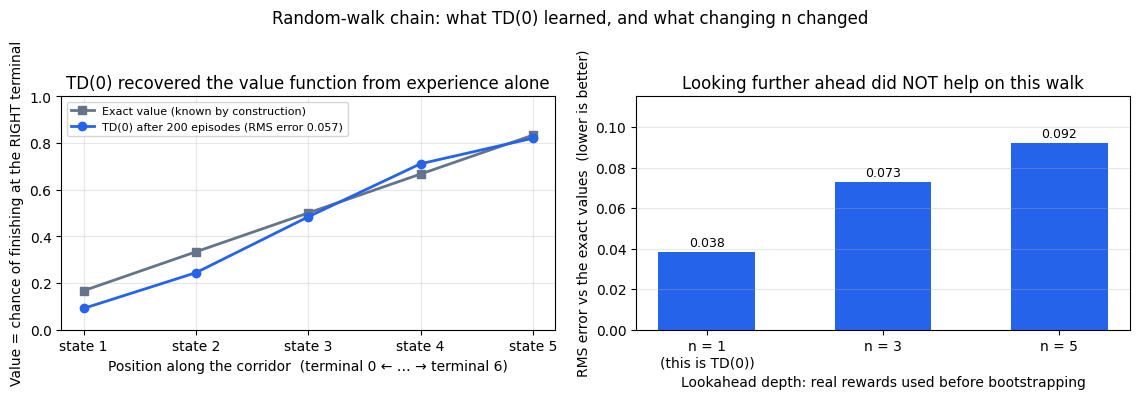

In [7]:
# Visual recap: the two claims Parts 2 and 3 printed as tables, drawn once as pictures.
# Nothing is re-trained here. This cell only reuses numbers the lesson already computed:
#   td0_chain_values -> Part 2's TD(0) estimates      TRUE_VALUES -> the exact answer
#   rmse_td0         -> Part 2's error                results_n   -> Part 3's error per n

# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt
# Load a library so you can use its ready-made functions and types below.
import numpy as np

# The five states an agent can actually act in; 0 and 6 are the terminals at each end.
chain_states = np.arange(1, 6)

# One figure, two panels: "did it learn the values?" and "did looking further ahead help?".
fig, (ax_values, ax_depth) = plt.subplots(1, 2, figsize=(11.5, 4.2))

# ── Left panel: TD(0)'s estimate against the exact value of every state ────────────
# The chain is a 1-D corridor, so joining the states with a line is meaningful:
# the x axis is physical position, and the exact value really is a straight ramp.
ax_values.plot(chain_states, TRUE_VALUES, marker="s", linewidth=2, color="#64748b",
               label="Exact value (known by construction)")
ax_values.plot(chain_states, td0_chain_values[1:6], marker="o", linewidth=2, color="#2563eb",
               label=f"TD(0) after 200 episodes (RMS error {rmse_td0:.3f})")
# Name every tick in words rather than leaving bare numbers on the axis.
ax_values.set_xticks(chain_states)
ax_values.set_xticklabels([f"state {s}" for s in chain_states])
ax_values.set_xlabel("Position along the corridor  (terminal 0 ← … → terminal 6)")
ax_values.set_ylabel("Value = chance of finishing at the RIGHT terminal")
ax_values.set_title("TD(0) recovered the value function from experience alone")
ax_values.set_ylim(0, 1)
ax_values.legend(loc="upper left", fontsize=8)
ax_values.grid(True, alpha=0.3)

# ── Right panel: error for each lookahead depth n ──────────────────────────────────
# n = 1, 3, 5 are three separate algorithms, not points on a curve, so they get BARS.
depths = sorted(results_n)
errors = [results_n[n] for n in depths]
bar_labels = [("n = 1\n(this is TD(0))" if n == 1 else f"n = {n}") for n in depths]
bars = ax_depth.bar(range(len(depths)), errors, width=0.55, color="#2563eb")
ax_depth.set_xticks(range(len(depths)))
ax_depth.set_xticklabels(bar_labels)
ax_depth.set_xlabel("Lookahead depth: real rewards used before bootstrapping")
ax_depth.set_ylabel("RMS error vs the exact values  (lower is better)")
ax_depth.set_title("Looking further ahead did NOT help on this walk")
# Print each bar's height on the bar so the reader never has to eyeball the axis.
for bar, err in zip(bars, errors):
    ax_depth.text(bar.get_x() + bar.get_width() / 2, err + max(errors) * 0.03,
                  f"{err:.3f}", ha="center", fontsize=9)
ax_depth.set_ylim(0, max(errors) * 1.25)
ax_depth.grid(True, alpha=0.3, axis="y")

fig.suptitle("Random-walk chain: what TD(0) learned, and what changing n changed", fontsize=12)
plt.tight_layout(rect=(0, 0.04, 1, 0.94))
plt.show()


### 👁️ Read the figure

- **Left panel — TD(0) found the ramp.** The grey squares are the exact answer, which for
  this chain happens to be a straight line from 1/6 at state 1 to 5/6 at state 5: the
  further right you start, the likelier you finish at the right-hand terminal. The blue
  circles are what TD(0) believed after 200 episodes, starting from a flat 0.5 everywhere
  and never once being shown the true numbers. Trace the gap: blue sits below grey at
  states 1 and 2, all but meets it at state 3, crosses slightly *above* at state 4, and lands just
  under it at state 5. After 200 episodes the shape is right and the levels are close but
  not finished — the size of that wobble is the RMS error printed in the legend.
- **Right panel — three algorithms, three bars.** `n` is the number of real rewards an
  update uses before it falls back on an existing estimate. These are three different
  algorithms, not three points on a trend, which is why they are bars and not a line.
  On this walk the shortest lookahead wins: **n = 1 (plain TD(0)) ends with the lowest
  error, and the error grows as n grows.**
- **The two panels use different episode streams.** The left panel is Part 2's run
  (generator seeded 42); the right panel re-runs all three depths on one shared stream
  (seed 7) so the comparison is fair. That is why n = 1's error on the right is not the
  same number as the left panel's legend — same algorithm, different random walks.

**What it proves:** bootstrapping works — you can learn a value function one step at a time
without ever finishing an episode, and without a model. And "look further ahead" is not
free advice: every extra real reward you wait for drags more of the walk's randomness into
the update. Here the variance cost beat the bias saving at every n above 1. On a different
environment it will not, which is exactly why the notebook measures it instead of asserting it.


## ⚠️ Where this breaks

**The assumption that has to hold:** your current estimate of the *next* state is good enough to
learn from. TD trains on its own predictions, which is its strength and its whole risk profile.

- **Bootstrapping means bias.** Monte Carlo's estimate is unbiased and noisy; TD's is biased and
  calm. Early in training, when `V(s')` is nonsense, TD is confidently propagating nonsense. It
  converges anyway in the tabular case — which is exactly the guarantee that disappears in the next
  bullet.
- **The deadly triad.** Combine bootstrapping with function approximation *and* off-policy updates
  and the tabular convergence guarantee is gone; the estimates can diverge outright. That combination
  is not exotic — it is a description of DQN, which is why Unit 3 spends its time on target networks
  and replay buffers. Van Hasselt et al., "Deep Reinforcement Learning and the Deadly Triad" (2018),
  is the reference; the fixes are engineering, not theory.
- **The step size decides whether it works.** These runs used `alpha = 0.1` and `alpha = 0.05`. Too
  large on a stochastic environment and each update simply overwrites the estimate with one lucky
  sample — Unit 3, lesson 05 measures a run where exactly that happens and the success rate collapses
  to 0.04.
- **n is a problem-specific guess.** Nothing here tells you the right n in advance. The two tables
  above disagree in detail even though both picked n=1, and both are single runs.
- **Cheaper alternative:** if you have the model, use it — one policy-evaluation sweep beats 3000
  sampled episodes and is exact. If episodes are short, cheap and plentiful, and you want an unbiased
  number you can defend in a meeting, Monte Carlo's honesty may be worth its variance.


## Closing Takeaway

**Teaching takeaway:** TD methods update before the episode ends by bootstrapping from current estimates, which makes learning faster and more incremental.

**If students remember one idea:** Temporal-difference learning is the bridge between Monte Carlo intuition and dynamic programming structure.

**Quick check before moving on:**
- Can you explain what bootstrapping means in TD learning?
- Can you describe how TD(0) and n-step TD trade off speed and target quality?

**Bridge to the next step:** With these update styles in mind, students can compare solution methods more clearly in the next lesson.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=22 | term=True | trunc=False


objc[69847]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x112424138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1129649c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[69847]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x112424188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x112964a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[69847]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x112423c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x112964a68). T

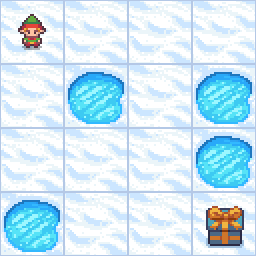

In [8]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
